# Zero-Shot Transfer Results

Plotting the results of zero-shot transfer experiments.

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.axes import Axes
from scipy.stats import binomtest

## Data

In [2]:
def convert_string(s: str):
    s = s.replace("[", "").replace("]","").strip().replace("nan", "-1")
    s = " ".join(s.split()).replace(" ", ",")
    return np.fromstring(s, sep=',').reshape((10, 10))

labels = ["Reg A", "Reg B", "Reg C", "Reg D", "Reg E", "Reg F", "Reg G", "Reg H", "Reg I", "Reg J"]

### In Distribution

In [3]:
# REG A
reg_a = convert_string("[[  nan 0.763 0.728 0.729 0.749 0.744 0.76  0.73  0.724 0.73 ]\
 [0.237   nan 0.481 0.514 0.495 0.511 0.501 0.526 0.5   0.52 ]\
 [0.272 0.519   nan 0.544 0.507 0.49  0.512 0.51  0.514 0.492]\
 [0.271 0.486 0.456   nan 0.519 0.467 0.513 0.476 0.482 0.483]\
 [0.251 0.505 0.493 0.481   nan 0.482 0.5   0.522 0.461 0.529]\
 [0.256 0.489 0.51  0.533 0.518   nan 0.566 0.529 0.499 0.507]\
 [0.24  0.499 0.488 0.487 0.5   0.434   nan 0.491 0.442 0.48 ]\
 [0.27  0.474 0.49  0.524 0.478 0.471 0.509   nan 0.519 0.529]\
 [0.276 0.5   0.486 0.518 0.539 0.501 0.558 0.481   nan 0.537]\
 [0.27  0.48  0.508 0.517 0.471 0.493 0.52  0.471 0.463   nan]]")
reg_a = np.where(reg_a==-1, np.nan, reg_a)

# REG B
reg_b = convert_string("[[  nan 0.295 0.538 0.526 0.519 0.508 0.559 0.505 0.53  0.54 ]\
 [0.705   nan 0.741 0.722 0.726 0.734 0.747 0.713 0.746 0.735]\
 [0.462 0.259   nan 0.526 0.505 0.503 0.509 0.497 0.516 0.536]\
 [0.474 0.278 0.474   nan 0.485 0.445 0.489 0.462 0.46  0.49 ]\
 [0.481 0.274 0.495 0.515   nan 0.508 0.508 0.482 0.508 0.517]\
 [0.492 0.266 0.497 0.555 0.492   nan 0.498 0.483 0.481 0.55 ]\
 [0.441 0.253 0.491 0.511 0.492 0.502   nan 0.485 0.473 0.504]\
 [0.495 0.287 0.503 0.538 0.518 0.517 0.515   nan 0.514 0.534]\
 [0.47  0.254 0.484 0.54  0.492 0.519 0.527 0.486   nan 0.525]\
 [0.46  0.265 0.464 0.51  0.483 0.45  0.496 0.466 0.475   nan]]")
reg_b = np.where(reg_b==-1, np.nan, reg_b)

# REG C
reg_c = convert_string("[[  nan 0.469 0.265 0.505 0.48  0.485 0.514 0.473 0.483 0.526]\
 [0.531   nan 0.266 0.504 0.525 0.506 0.518 0.448 0.488 0.494]\
 [0.735 0.734   nan 0.73  0.729 0.731 0.732 0.709 0.728 0.73 ]\
 [0.495 0.496 0.27    nan 0.442 0.481 0.508 0.48  0.485 0.51 ]\
 [0.52  0.475 0.271 0.558   nan 0.518 0.523 0.485 0.488 0.506]\
 [0.515 0.494 0.269 0.519 0.482   nan 0.546 0.48  0.522 0.5  ]\
 [0.486 0.482 0.268 0.492 0.477 0.454   nan 0.479 0.495 0.481]\
 [0.527 0.552 0.291 0.52  0.515 0.52  0.521   nan 0.528 0.524]\
 [0.517 0.512 0.272 0.515 0.512 0.478 0.505 0.472   nan 0.53 ]\
 [0.474 0.506 0.27  0.49  0.494 0.5   0.519 0.476 0.47    nan]]")
reg_c = np.where(reg_c==-1, np.nan, reg_c)

# REG D
reg_d = convert_string("[[  nan 0.527 0.467 0.217 0.413 0.441 0.484 0.48  0.467 0.46 ]\
 [0.473   nan 0.463 0.224 0.419 0.461 0.446 0.476 0.47  0.425]\
 [0.533 0.537   nan 0.273 0.491 0.526 0.512 0.52  0.53  0.536]\
 [0.783 0.776 0.727   nan 0.714 0.736 0.754 0.777 0.757 0.718]\
 [0.587 0.581 0.509 0.286   nan 0.552 0.539 0.507 0.537 0.531]\
 [0.559 0.539 0.474 0.264 0.448   nan 0.489 0.523 0.507 0.542]\
 [0.516 0.554 0.488 0.246 0.461 0.511   nan 0.502 0.524 0.514]\
 [0.52  0.524 0.48  0.223 0.493 0.477 0.498   nan 0.488 0.528]\
 [0.533 0.53  0.47  0.243 0.463 0.493 0.476 0.512   nan 0.496]\
 [0.54  0.575 0.464 0.282 0.469 0.458 0.486 0.472 0.504   nan]]")
reg_d = np.where(reg_d==-1, np.nan, reg_d)

# REG E
reg_e = convert_string("[[  nan 0.519 0.543 0.493 0.275 0.471 0.559 0.522 0.524 0.534]\
 [0.481   nan 0.541 0.476 0.239 0.449 0.524 0.499 0.478 0.508]\
 [0.457 0.459   nan 0.468 0.243 0.447 0.506 0.491 0.497 0.478]\
 [0.507 0.524 0.532   nan 0.296 0.473 0.569 0.498 0.53  0.499]\
 [0.725 0.761 0.757 0.704   nan 0.717 0.758 0.748 0.721 0.716]\
 [0.529 0.551 0.553 0.527 0.283   nan 0.585 0.535 0.492 0.531]\
 [0.441 0.476 0.494 0.431 0.242 0.415   nan 0.469 0.46  0.475]\
 [0.478 0.501 0.509 0.502 0.252 0.465 0.531   nan 0.497 0.489]\
 [0.476 0.522 0.503 0.47  0.279 0.508 0.54  0.503   nan 0.487]\
 [0.466 0.492 0.522 0.501 0.284 0.469 0.525 0.511 0.513   nan]]")
reg_e = np.where(reg_e==-1, np.nan, reg_e)

# REG F
reg_f = convert_string("[[  nan 0.507 0.484 0.52  0.483 0.295 0.486 0.468 0.486 0.473]\
 [0.493   nan 0.476 0.492 0.457 0.328 0.469 0.48  0.518 0.469]\
 [0.516 0.524   nan 0.484 0.468 0.327 0.492 0.524 0.532 0.487]\
 [0.48  0.508 0.516   nan 0.474 0.319 0.493 0.485 0.511 0.433]\
 [0.517 0.543 0.532 0.526   nan 0.352 0.53  0.559 0.501 0.509]\
 [0.705 0.672 0.673 0.681 0.648   nan 0.645 0.642 0.657 0.643]\
 [0.514 0.531 0.508 0.507 0.47  0.355   nan 0.511 0.5   0.475]\
 [0.532 0.52  0.476 0.515 0.441 0.358 0.489   nan 0.499 0.51 ]\
 [0.514 0.482 0.468 0.489 0.499 0.343 0.5   0.501   nan 0.494]\
 [0.527 0.531 0.513 0.567 0.491 0.357 0.525 0.49  0.506   nan]]")
reg_f = np.where(reg_f==-1, np.nan, reg_f)

# REG G
reg_g = convert_string("[[  nan 0.499 0.487 0.447 0.487 0.47  0.214 0.445 0.385 0.417]\
 [0.501   nan 0.442 0.418 0.486 0.469 0.191 0.417 0.383 0.356]\
 [0.513 0.558   nan 0.485 0.542 0.484 0.264 0.5   0.406 0.415]\
 [0.553 0.582 0.515   nan 0.537 0.516 0.258 0.505 0.45  0.427]\
 [0.513 0.514 0.458 0.463   nan 0.533 0.225 0.441 0.406 0.415]\
 [0.53  0.531 0.516 0.484 0.467   nan 0.245 0.493 0.449 0.41 ]\
 [0.786 0.809 0.736 0.742 0.775 0.755   nan 0.748 0.678 0.717]\
 [0.555 0.583 0.5   0.495 0.559 0.507 0.252   nan 0.451 0.452]\
 [0.615 0.617 0.594 0.55  0.594 0.551 0.322 0.549   nan 0.523]\
 [0.583 0.644 0.585 0.573 0.585 0.59  0.283 0.548 0.477   nan]]")
reg_g = np.where(reg_g==-1, np.nan, reg_g)

# REG H
reg_h = convert_string("[[  nan 0.495 0.535 0.487 0.49  0.479 0.531 0.307 0.488 0.468]\
 [0.505   nan 0.517 0.531 0.543 0.506 0.524 0.274 0.502 0.507]\
 [0.465 0.483   nan 0.501 0.512 0.45  0.506 0.285 0.494 0.486]\
 [0.513 0.469 0.499   nan 0.502 0.503 0.489 0.3   0.514 0.495]\
 [0.51  0.457 0.488 0.498   nan 0.511 0.503 0.29  0.494 0.447]\
 [0.521 0.494 0.55  0.497 0.489   nan 0.52  0.338 0.508 0.478]\
 [0.469 0.476 0.494 0.511 0.497 0.48    nan 0.281 0.484 0.484]\
 [0.693 0.726 0.715 0.7   0.71  0.662 0.719   nan 0.678 0.695]\
 [0.512 0.498 0.506 0.486 0.506 0.492 0.516 0.322   nan 0.482]\
 [0.532 0.493 0.514 0.505 0.553 0.522 0.516 0.305 0.518   nan]]")
reg_h = np.where(reg_h==-1, np.nan, reg_h)

# REG I
reg_i = convert_string("[[  nan 0.548 0.428 0.405 0.499 0.425 0.384 0.44  0.227 0.363]\
 [0.452   nan 0.409 0.387 0.415 0.392 0.295 0.379 0.202 0.324]\
 [0.572 0.591   nan 0.493 0.533 0.503 0.443 0.487 0.223 0.401]\
 [0.595 0.613 0.507   nan 0.54  0.499 0.408 0.49  0.269 0.456]\
 [0.501 0.585 0.467 0.46    nan 0.477 0.4   0.485 0.241 0.403]\
 [0.575 0.608 0.497 0.501 0.523   nan 0.429 0.493 0.279 0.421]\
 [0.616 0.705 0.557 0.592 0.6   0.571   nan 0.574 0.283 0.499]\
 [0.56  0.621 0.513 0.51  0.515 0.507 0.426   nan 0.251 0.407]\
 [0.773 0.798 0.777 0.731 0.759 0.721 0.717 0.749   nan 0.7  ]\
 [0.637 0.676 0.599 0.544 0.597 0.579 0.501 0.593 0.3     nan]]")
reg_i = np.where(reg_i==-1, np.nan, reg_i)

# REG J
reg_j = convert_string("[[  nan 0.544 0.469 0.48  0.452 0.425 0.413 0.427 0.373 0.196]\
 [0.456   nan 0.414 0.463 0.423 0.414 0.389 0.398 0.338 0.177]\
 [0.531 0.586   nan 0.48  0.486 0.485 0.463 0.466 0.416 0.243]\
 [0.52  0.537 0.52    nan 0.524 0.497 0.444 0.495 0.411 0.252]\
 [0.548 0.577 0.514 0.476   nan 0.471 0.439 0.499 0.434 0.228]\
 [0.575 0.586 0.515 0.503 0.529   nan 0.475 0.525 0.452 0.296]\
 [0.587 0.611 0.537 0.556 0.561 0.525   nan 0.536 0.439 0.27 ]\
 [0.573 0.602 0.534 0.505 0.501 0.475 0.464   nan 0.448 0.252]\
 [0.627 0.662 0.584 0.589 0.566 0.548 0.561 0.552   nan 0.3  ]\
 [0.804 0.823 0.757 0.748 0.772 0.704 0.73  0.748 0.7     nan]]")
reg_j = np.where(reg_j==-1, np.nan, reg_j)

### Out of Distribution

In [4]:
# REG A
out_reg_a = convert_string("[[  nan 0.536 0.518 0.543 0.511 0.529 0.499 0.511 0.546 0.547]\
 [0.464   nan 0.513 0.564 0.499 0.506 0.493 0.524 0.508 0.519]\
 [0.482 0.487   nan 0.514 0.467 0.499 0.5   0.499 0.516 0.511]\
 [0.457 0.436 0.486   nan 0.455 0.453 0.472 0.46  0.486 0.489]\
 [0.489 0.501 0.533 0.545   nan 0.506 0.51  0.517 0.498 0.504]\
 [0.471 0.494 0.501 0.547 0.494   nan 0.507 0.521 0.557 0.551]\
 [0.501 0.507 0.5   0.528 0.49  0.493   nan 0.467 0.532 0.495]\
 [0.489 0.476 0.501 0.54  0.483 0.479 0.533   nan 0.548 0.525]\
 [0.454 0.492 0.484 0.514 0.502 0.443 0.468 0.452   nan 0.478]\
 [0.453 0.481 0.489 0.511 0.496 0.449 0.505 0.475 0.522   nan]]")
out_reg_a = np.where(out_reg_a==-1, np.nan, out_reg_a)

# REG C
out_reg_c = convert_string("[[  nan 0.519 0.472 0.47  0.491 0.488 0.507 0.462 0.476 0.494]\
 [0.481   nan 0.454 0.493 0.47  0.499 0.482 0.473 0.477 0.468]\
 [0.528 0.546   nan 0.525 0.49  0.527 0.523 0.456 0.486 0.482]\
 [0.53  0.507 0.475   nan 0.516 0.491 0.507 0.467 0.477 0.469]\
 [0.509 0.53  0.51  0.484   nan 0.529 0.511 0.474 0.489 0.472]\
 [0.512 0.501 0.473 0.509 0.471   nan 0.49  0.487 0.468 0.457]\
 [0.493 0.518 0.477 0.493 0.489 0.51    nan 0.487 0.466 0.48 ]\
 [0.538 0.527 0.544 0.533 0.526 0.513 0.513   nan 0.49  0.518]\
 [0.524 0.523 0.514 0.523 0.511 0.532 0.534 0.51    nan 0.459]\
 [0.506 0.532 0.518 0.531 0.528 0.543 0.52  0.482 0.541   nan]]")
out_reg_c = np.where(out_reg_c==-1, np.nan, out_reg_c)

# REG D
out_reg_d = convert_string("[[  nan 0.525 0.51  0.443 0.449 0.456 0.488 0.49  0.509 0.519]\
 [0.475   nan 0.507 0.421 0.426 0.479 0.478 0.447 0.454 0.488]\
 [0.49  0.493   nan 0.445 0.441 0.49  0.46  0.474 0.469 0.504]\
 [0.557 0.579 0.555   nan 0.482 0.503 0.513 0.508 0.51  0.544]\
 [0.551 0.574 0.559 0.518   nan 0.52  0.517 0.52  0.521 0.57 ]\
 [0.544 0.521 0.51  0.497 0.48    nan 0.538 0.496 0.521 0.539]\
 [0.512 0.522 0.54  0.487 0.483 0.462   nan 0.496 0.497 0.511]\
 [0.51  0.553 0.526 0.492 0.48  0.504 0.504   nan 0.492 0.533]\
 [0.491 0.546 0.531 0.49  0.479 0.479 0.503 0.508   nan 0.515]\
 [0.481 0.512 0.496 0.456 0.43  0.461 0.489 0.467 0.485   nan]]")
out_reg_d = np.where(out_reg_d==-1, np.nan, out_reg_d)

# REG F
out_reg_f = convert_string("[[  nan 0.501 0.49  0.494 0.49  0.478 0.43  0.462 0.493 0.445]\
 [0.499   nan 0.512 0.501 0.481 0.466 0.452 0.443 0.462 0.471]\
 [0.51  0.488   nan 0.476 0.467 0.463 0.46  0.475 0.474 0.461]\
 [0.506 0.499 0.524   nan 0.485 0.485 0.475 0.459 0.474 0.465]\
 [0.51  0.519 0.533 0.515   nan 0.499 0.468 0.486 0.444 0.498]\
 [0.522 0.534 0.537 0.515 0.501   nan 0.497 0.515 0.498 0.5  ]\
 [0.57  0.548 0.54  0.525 0.532 0.503   nan 0.515 0.493 0.505]\
 [0.538 0.557 0.525 0.541 0.514 0.485 0.485   nan 0.497 0.521]\
 [0.507 0.538 0.526 0.526 0.556 0.502 0.507 0.503   nan 0.482]\
 [0.555 0.529 0.539 0.535 0.502 0.5   0.495 0.479 0.518   nan]]")
out_reg_f = np.where(out_reg_f==-1, np.nan, out_reg_f)

# REG G
out_reg_g = convert_string("[[  nan 0.549 0.553 0.473 0.486 0.505 0.468 0.531 0.436 0.436]\
 [0.451   nan 0.431 0.427 0.444 0.454 0.405 0.408 0.348 0.37 ]\
 [0.447 0.569   nan 0.468 0.436 0.478 0.404 0.436 0.424 0.415]\
 [0.527 0.573 0.532   nan 0.514 0.504 0.47  0.474 0.445 0.436]\
 [0.514 0.556 0.564 0.486   nan 0.49  0.452 0.482 0.445 0.453]\
 [0.495 0.546 0.522 0.496 0.51    nan 0.465 0.495 0.436 0.424]\
 [0.532 0.595 0.596 0.53  0.548 0.535   nan 0.553 0.493 0.5  ]\
 [0.469 0.592 0.564 0.526 0.518 0.505 0.447   nan 0.428 0.46 ]\
 [0.564 0.652 0.576 0.555 0.555 0.564 0.507 0.572   nan 0.508]\
 [0.564 0.63  0.585 0.564 0.547 0.576 0.5   0.54  0.492   nan]]")
out_reg_g = np.where(out_reg_g==-1, np.nan, out_reg_g)

# REG H
out_reg_h = convert_string("[[  nan 0.532 0.55  0.55  0.499 0.46  0.517 0.52  0.514 0.528]\
 [0.468   nan 0.5   0.434 0.447 0.46  0.489 0.464 0.481 0.474]\
 [0.45  0.5     nan 0.491 0.474 0.448 0.439 0.489 0.493 0.473]\
 [0.45  0.566 0.509   nan 0.461 0.478 0.5   0.458 0.511 0.468]\
 [0.501 0.553 0.526 0.539   nan 0.514 0.509 0.503 0.544 0.517]\
 [0.54  0.54  0.552 0.522 0.486   nan 0.531 0.529 0.515 0.491]\
 [0.483 0.511 0.561 0.5   0.491 0.469   nan 0.463 0.492 0.5  ]\
 [0.48  0.536 0.511 0.542 0.497 0.471 0.537   nan 0.52  0.516]\
 [0.486 0.519 0.507 0.489 0.456 0.485 0.508 0.48    nan 0.49 ]\
 [0.472 0.526 0.527 0.532 0.483 0.509 0.5   0.484 0.51    nan]]")
out_reg_h = np.where(out_reg_h==-1, np.nan, out_reg_h)

# REG I
out_reg_i = convert_string("[[  nan 0.552 0.491 0.416 0.504 0.497 0.432 0.474 0.402 0.399]\
 [0.448   nan 0.438 0.397 0.443 0.407 0.373 0.421 0.368 0.339]\
 [0.509 0.562   nan 0.473 0.499 0.47  0.437 0.519 0.439 0.435]\
 [0.584 0.603 0.527   nan 0.535 0.552 0.428 0.532 0.442 0.45 ]\
 [0.496 0.557 0.501 0.465   nan 0.468 0.402 0.485 0.412 0.419]\
 [0.503 0.593 0.53  0.448 0.532   nan 0.443 0.516 0.442 0.391]\
 [0.568 0.627 0.563 0.572 0.598 0.557   nan 0.558 0.482 0.479]\
 [0.526 0.579 0.481 0.468 0.515 0.484 0.442   nan 0.412 0.408]\
 [0.598 0.632 0.561 0.558 0.588 0.558 0.518 0.588   nan 0.51 ]\
 [0.601 0.661 0.565 0.55  0.581 0.609 0.521 0.592 0.49    nan]]")
out_reg_i = np.where(out_reg_i==-1, np.nan, out_reg_i)

## Plotting

In [17]:
def heatmap(reg: str, ax: Axes, cbar_ax: Axes | None = None, out_of_dist: bool = False):
    variables = globals()
    sns.heatmap(
        variables[("out_" if out_of_dist else "") + "reg_" + reg.lower()],
        vmin=0, # lower bound of cmap
        vmax=1, # upper bound of cmap
        annot=False,
        cmap="viridis",
        linewidth=0.5, # spacing between squares
        xticklabels=[l[4:] for l in labels],
        yticklabels=[l[4:] for l in labels],
        ax=ax,
        cbar_ax=cbar_ax
    )
    ax.set_title(f"Reg. {reg.upper()}")
    for _, spine in ax.spines.items():
        spine.set_visible(True) # borders around heatmap

C:\Users\Thoma\AppData\Local\Temp\ipykernel_7032\2883871230.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


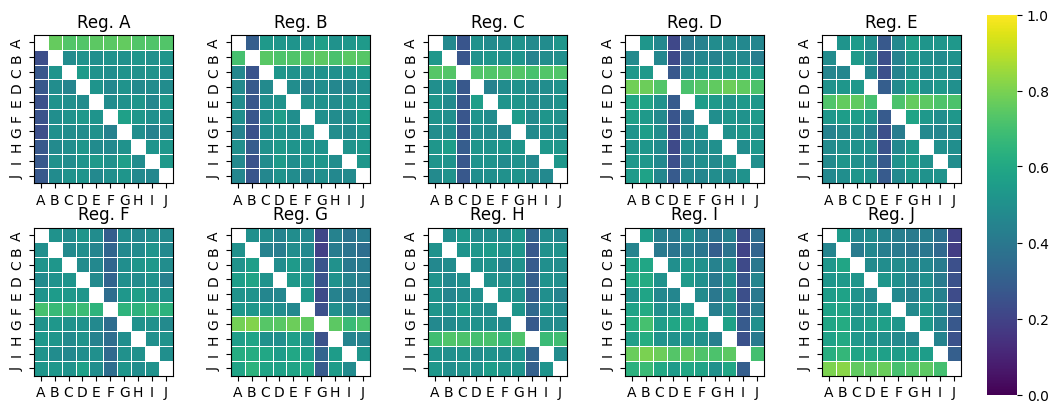

In [18]:
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
cbar_ax = fig.add_axes((1, .05, .03, .95))
fig.tight_layout()
heatmap("A", axs[0,0], cbar_ax)
heatmap("B", axs[0,1], cbar_ax)
heatmap("C", axs[0,2], cbar_ax)
heatmap("D", axs[0,3], cbar_ax)
heatmap("E", axs[0,4], cbar_ax)
heatmap("F", axs[1,0], cbar_ax)
heatmap("G", axs[1,1], cbar_ax)
heatmap("H", axs[1,2], cbar_ax)
heatmap("I", axs[1,3], cbar_ax)
heatmap("J", axs[1,4], cbar_ax)
plt.show()

C:\Users\Thoma\AppData\Local\Temp\ipykernel_7032\189332808.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


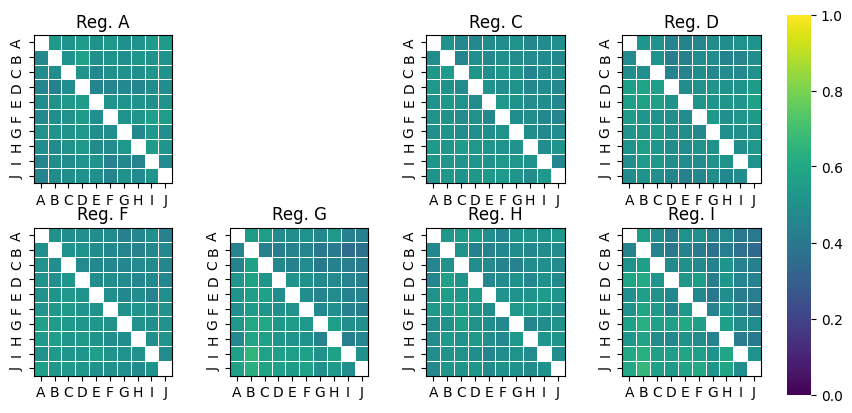

In [19]:
fig, axs = plt.subplots(2, 4, figsize=(8, 4))
cbar_ax = fig.add_axes((1, .05, .03, .95))
fig.tight_layout()
heatmap("A", axs[0,0], cbar_ax, True)
axs[0,1].axis('off') # gap for reg B
heatmap("C", axs[0,2], cbar_ax, True)
heatmap("D", axs[0,3], cbar_ax, True)
heatmap("F", axs[1,0], cbar_ax, True)
heatmap("G", axs[1,1], cbar_ax, True)
heatmap("H", axs[1,2], cbar_ax, True)
heatmap("I", axs[1,3], cbar_ax, True)
plt.show()

### Extra Figures

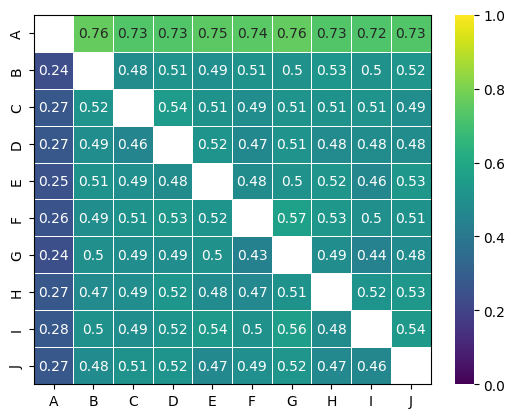

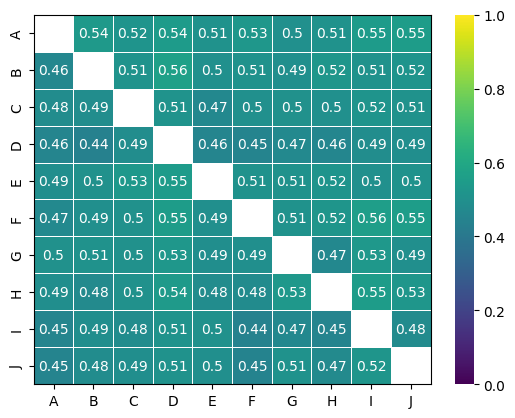

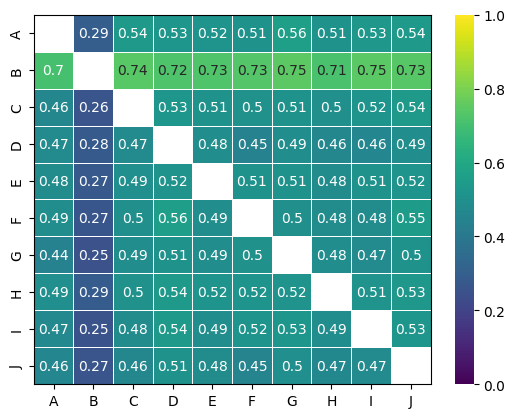

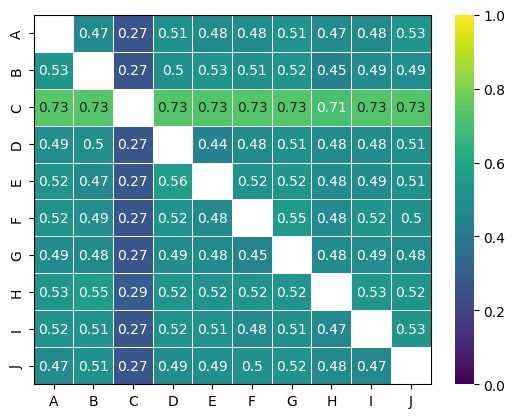

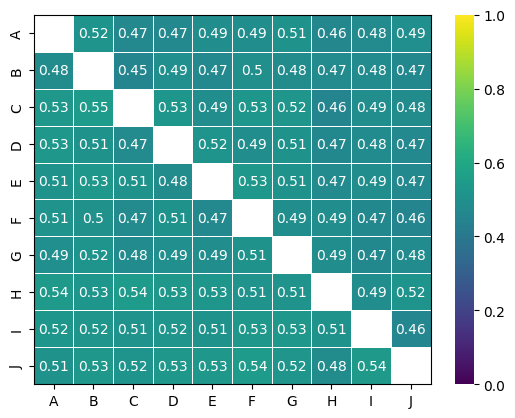

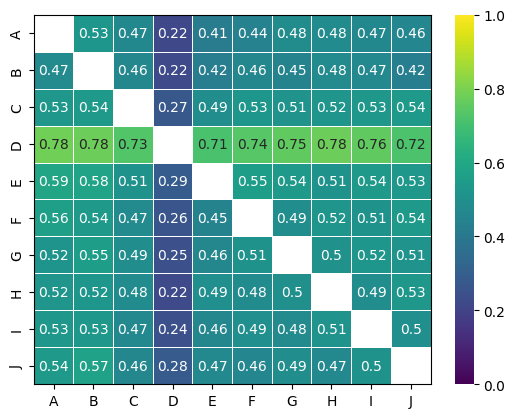

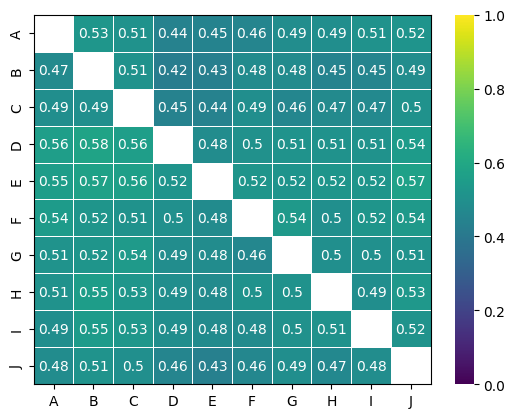

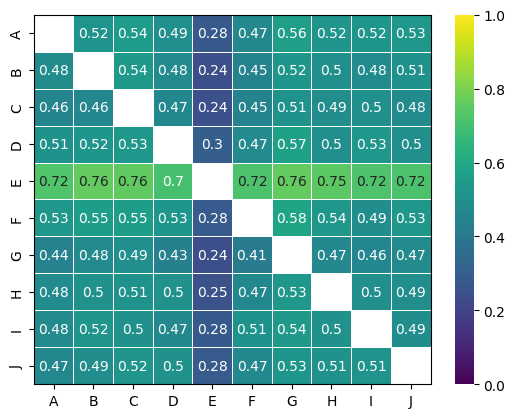

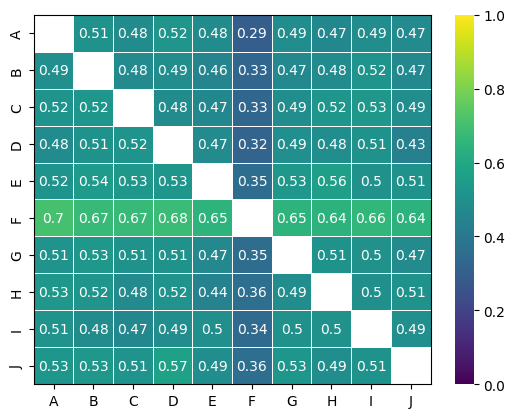

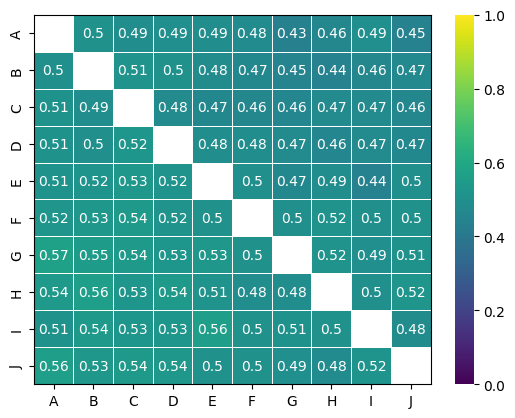

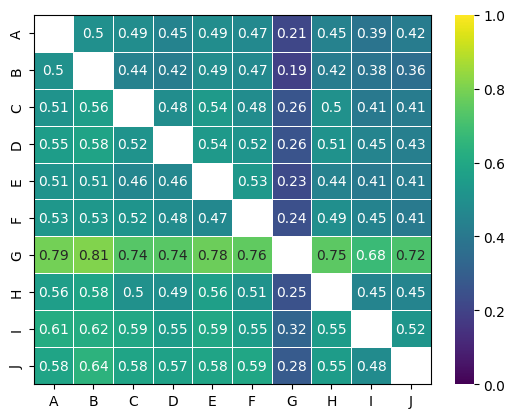

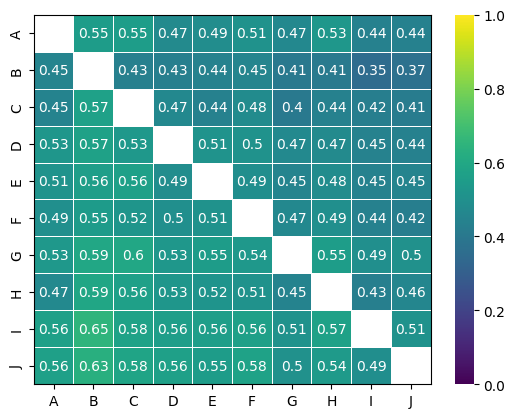

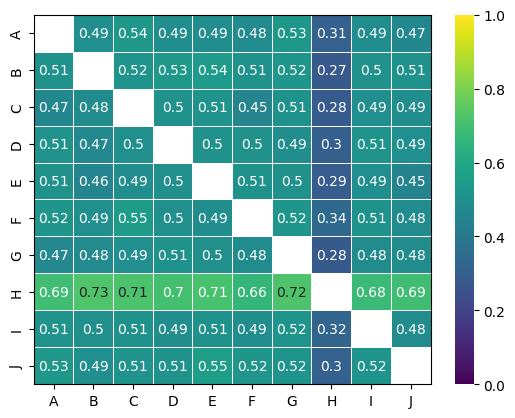

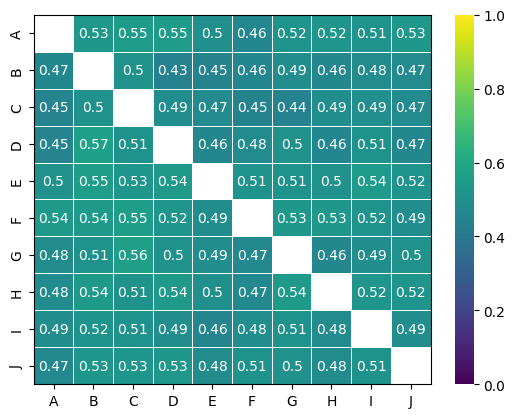

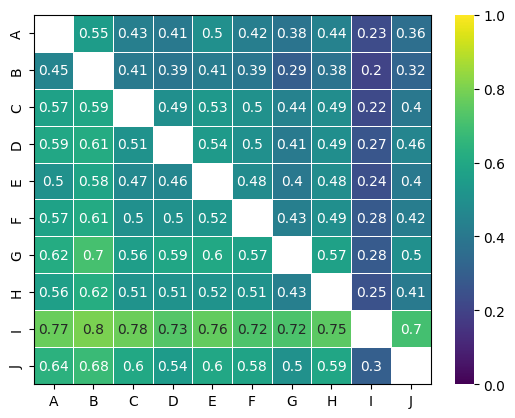

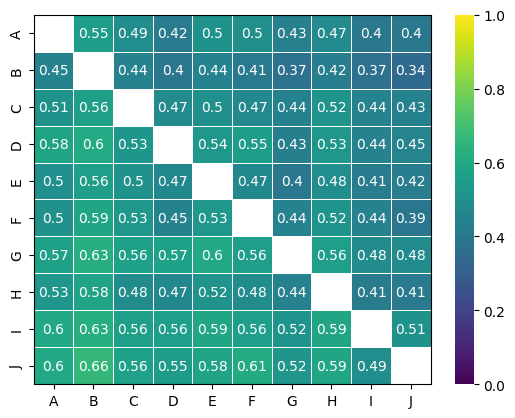

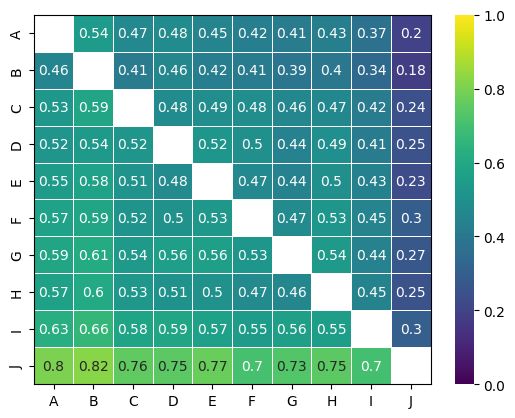

In [7]:
def heatmap_ind(reg: str, out_of_dist: bool = False):
    variables = globals()
    ax = sns.heatmap(
        variables[("out_" if out_of_dist else "") + "reg_" + reg.lower()],
        vmin=0, # lower bound of cmap
        vmax=1, # upper bound of cmap
        annot=True,
        cmap="viridis",
        linewidth=0.5, # spacing between squares
        xticklabels=[l[4:] for l in labels],
        yticklabels=[l[4:] for l in labels],
    )
    for _, spine in ax.spines.items():
        spine.set_visible(True) # borders around heatmap

for reg in labels:
    heatmap_ind(reg[4:])
    plt.show()
    if not reg[4:] in ["B", "E", "J"]:
        heatmap_ind(reg[4:], True)
        plt.show()

### P-Values

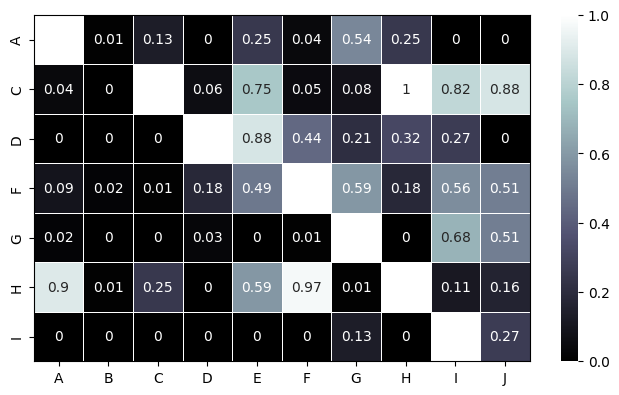

In [14]:
out_of_dist = True

regs_full = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"]
regs_out = ["A", "C", "D", "F", "G", "H", "I"]
regs = regs_out if out_of_dist else regs_full

results = np.zeros((len(regs),len(regs_full)))

variables = globals()
for i, reg in enumerate(regs):
    results[i] = variables[("out_" if len(regs) < 10 else "") + "reg_" + reg.lower()][regs_full.index(reg)]

for i in range(results.shape[0]):
    for j in range(results.shape[1]):
        if regs[i] is not regs_full[j]:
            results[i,j] = binomtest(k=int(results[i,j]*1000), n=1000, p=0.5, alternative="greater").pvalue

if out_of_dist:
    plt.figure(figsize=(8, 4.5))
ax = sns.heatmap(
    results.round(decimals=2),
    vmin=0, # lower bound of cmap
    vmax=1, # upper bound of cmap
    annot=True,
    cmap="bone",
    linewidth=0.5, # spacing between squares
    xticklabels=[l for l in regs_full],
    yticklabels=[l for l in regs],
)
for _, spine in ax.spines.items():
    spine.set_visible(True) # borders around heatmap
plt.show()